# Reaction-Diffusion Equation

The reaction-diffusion equation combines spatial diffusion with a local reaction term:

$$\frac{\partial u}{\partial t} = D\,\nabla^2 u + R(u)$$

Depending on the reaction term $R$, the solution can exhibit travelling waves, pattern formation, or bistability.

We demonstrate the **Fisher-KPP equation** — a model for the spread of an advantageous gene or invasive species:

$$\frac{\partial u}{\partial t} = D\,\frac{\partial^2 u}{\partial x^2} + r\,u(1-u)$$

Starting from a localised initial condition, the solution develops a travelling wave that propagates at speed $c^* = 2\sqrt{rD}$.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
# import sys; sys.path.insert(0, '..')   # adjust path to upde.py and equations.py
# run pip install -e . to install package
from upde import PDE, PDESystem, ReactionDiffusion

Theoretical wave speed: c* = 1.414


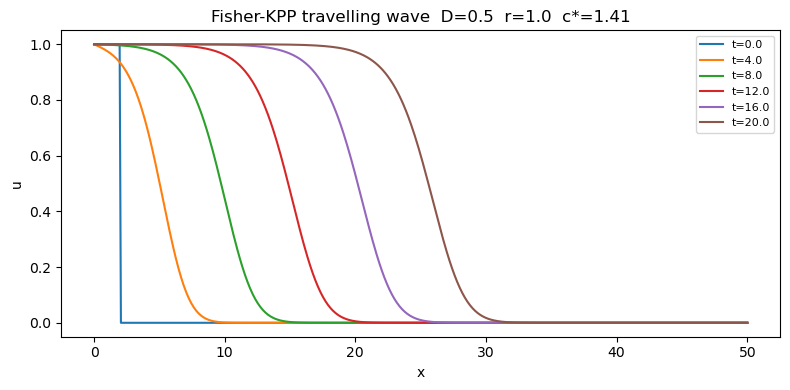

In [4]:
x = np.linspace(0, 50, 512)
D = 0.5
r = 1.0
c_theory = 2 * np.sqrt(r * D)
print(f'Theoretical wave speed: c* = {c_theory:.3f}')

eq = ReactionDiffusion('u', x=x, diffusivity=D,
                        reaction=lambda x, u: r * u * (1 - u))
eq.set_bc(side='left',  kind='dirichlet', value=1.0)
eq.set_bc(side='right', kind='dirichlet', value=0.0)
eq.set_ic(lambda x: (x < 2.0).astype(float))

sol = eq.solve(t_span=(0, 20), method='BDF',
                            t_eval=np.linspace(0, 20, 6),
                            rtol=1e-4, atol=1e-6)

fig, ax = plt.subplots(figsize=(8, 4))
for k, t in enumerate(sol.t):
    ax.plot(x, sol.u[:, k], label=f't={t:.1f}')
ax.set_xlabel('x'); ax.set_ylabel('u')
ax.set_title(f'Fisher-KPP travelling wave  D={D}  r={r}  c*={c_theory:.2f}')
ax.legend(fontsize=8); plt.tight_layout(); plt.show()
